In [1]:
a=1

# Maravillo plot 2

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids

In [3]:
from scripts import style
style.mpl_apply()  

In [4]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

In [6]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

In [11]:
# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()

# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)

# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)

# add the timmes each id appears as a new column 'asesoria_count' in asesorias
materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)

# get the profes ids
profes_ids = materias['CLAVEPROFESOR'].unique()

In [9]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2: return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float); k = 0
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        take = min(ok.sum(), batch)
        if take:
            out[k:k+take] = draw[ok][:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.4, min_kde_n=20, seed=42,
    fallback='uniform',           # 'constant' | 'global' | 'parametric' | 'leave' | 'uniform'
    constant_value=6.5,
    prefer_empirical_if_small=True,
    global_source=None,
    debug=False
):
    rng = np.random.default_rng(seed)
    df = df.copy()

    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num
    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df

    obs_pre = num[~num.isna() & (num <= high)]

    def _borrow_pool():
        src = pd.to_numeric(global_source, errors='coerce') if global_source is not None else num
        return src[(~src.isna()) & (src <= high)]

    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif 0 < len(obs_pre) < min_kde_n:
        draws = np.clip(_sample_empirical(obs_pre.values, need, rng=rng), low, high)
    else:
        # No mass in [low, high]; choose fallback
        if fallback == 'global':
            pool = _borrow_pool()
            if len(pool) >= min_kde_n:
                draws = _sample_kde_truncated(pool.values, need, low=low, high=high, rng=rng)
            elif len(pool) > 0:
                draws = np.clip(_sample_empirical(pool.values, need, rng=rng), low, high)
            else:
                draws = np.full(need, min(constant_value, high))
        elif fallback == 'parametric':
            obs_all = num[~num.isna()]
            mu = float(obs_all.mean()) if len(obs_all) else 6.5
            sd = float(obs_all.std(ddof=1)) if len(obs_all) > 1 else 0.5
            sd = max(sd, 1e-3)
            k, draws = 0, np.empty(need)
            while k < need:
                batch = need - k
                cand = rng.normal(mu, sd, size=batch)
                ok = (cand >= low) & (cand <= high)
                take = min(ok.sum(), batch)
                if take:
                    draws[k:k+take] = cand[ok][:take]
                    k += take
        elif fallback == 'uniform':
            # Equally spaced interior points in [low, high]
            # order matches the order of NaNs in the DataFrame
            ks = np.arange(1, need + 1, dtype=float)
            draws = low + (ks / (need + 1.0)) * (high - low)
        elif fallback == 'leave':
            return df
        elif fallback == 'constant':
            draws = np.full(need, min(constant_value, high))
        else:
            raise ValueError("Unknown fallback")

    df.loc[nan_mask, out_col] = draws
    # hard bounds only on imputed entries
    vals = df.loc[nan_mask, out_col].to_numpy(dtype=float, copy=False)
    np.clip(vals, low, high, out=vals)
    df.loc[nan_mask, out_col] = vals
    return df


In [12]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                sesion_materias = impute_nans_from_pre75_kde_df(
                    sesion_materias,
                    value_col='CALIFICACION',
                    out_col='IMPKDE'
                )
                mean = sesion_materias['IMPKDE'].mean()
                std = sesion_materias['IMPKDE'].std()
                sesion_materias['IMPKDE_Z'] = (sesion_materias['IMPKDE'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

C:\Users\herie\AppData\Local\Temp\ipykernel_21376\2741904170.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
C:\Users\herie\AppData\Local\Temp\ipykernel_21376\2741904170.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
C:\Users\herie\AppData\Local\Temp\ipykernel_21376\2741904170.py:19: SettingWithCopyWarning: 

In [13]:
ultramerge = pd.concat(salones.values(), ignore_index=True)
ultramerge.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0,2,6.216667,-1.077958,6.9,-0.566673
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0,2,7.600000,-0.355548,7.6,-0.252686
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0,7,7.500000,-0.407770,7.5,-0.297541
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0,0,6.900000,-0.721105,6.9,-0.566673
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0,0,6.216667,-1.077958,7.0,-0.521818


## View the difference in distributions by KS-clustered professors

In [14]:
# clave profesor nunique
profes_value_counts = materias['CLAVEPROFESOR'].value_counts()
profes_value_counts

# ---- color scaling by counts (your code kept) ----
scaler = MinMaxScaler()
counts = profes_value_counts.values.reshape(-1, 1)
scaled_counts = scaler.fit_transform(counts)

viridis_by_prof = [sns.color_palette("Blues_r", 100)[int(scaled_counts[i][0]*50)]
                   for i in range(len(scaled_counts))]
magma_by_prof = [sns.color_palette("Reds_r", 100)[int(scaled_counts[i][0]*50)]
                   for i in range(len(scaled_counts))]

threshold = 7.5

In [15]:
# calculate the percentage of CALIFICACION above and below the threshold for each professor
below_threshold_percentages = []
above_threshold_percentages = []
for num in range(len(profes_ids)):
    profe = materias[materias['CLAVEPROFESOR'] == profes_ids[num]]
    profe_num = profe[pd.to_numeric(profe['CALIFICACION'], errors='coerce').notnull()]
    calificaciones = profe_num['CALIFICACION'].astype(float)
    total_count = len(calificaciones)
    if total_count == 0:
        below_threshold_percentages.append(0)
        above_threshold_percentages.append(0)
        continue
    below_count = (calificaciones < threshold).sum()
    above_count = (calificaciones >= threshold).sum()
    below_threshold_percentages.append(below_count / total_count)
    above_threshold_percentages.append(above_count / total_count)

# get the mean
mean_below = np.mean(below_threshold_percentages)
mean_above = np.mean(above_threshold_percentages)

IndexError: list index out of range

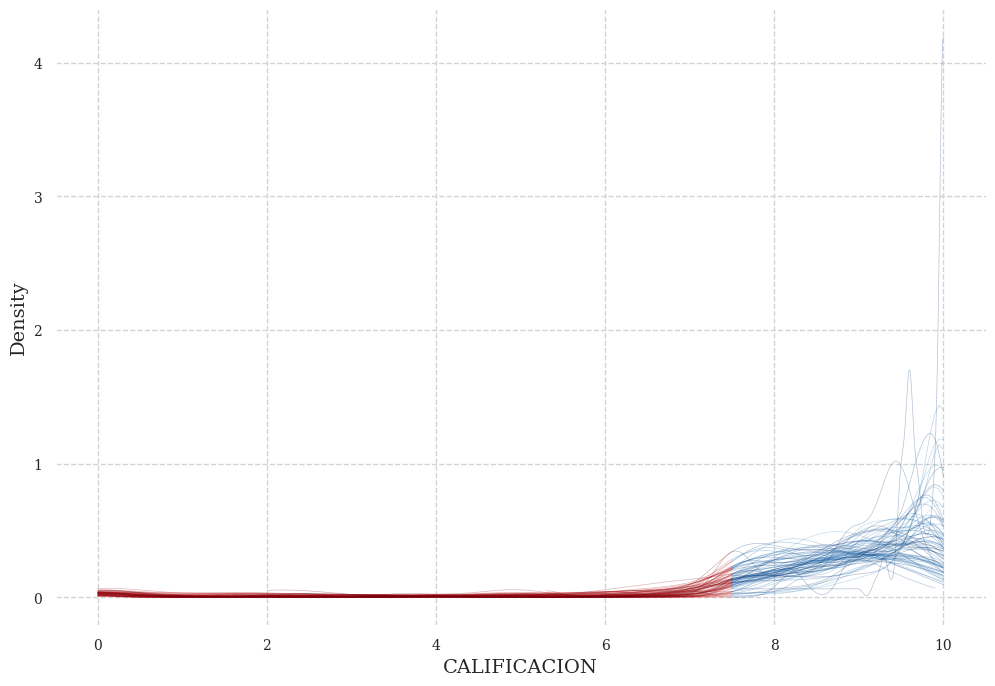

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))

for num, prof_id in enumerate(profes_ids):
    profe2 = ultramerge[ultramerge['CLAVEPROFESOR'] == prof_id]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    if profe2num.empty:
        continue

    # draw KDE invisibly to obtain its sampled x,y from seaborn
    sns.kdeplot(
        profe2num['CALIFICACION'],
        cut=0, bw_adjust=0.5, clip=(0, 10),
        color='none', linewidth=0, ax=ax
    )
    x, y = ax.lines[-1].get_data()
    ax.lines[-1].remove()  # remove the invisible line

    # ensure x is strictly increasing for interpolation safety
    order = np.argsort(x)
    x, y = x[order], y[order]

    # interpolate y at the split point to avoid a visual gap
    y_thr = np.interp(threshold, x, y)

    # left segment: x <= threshold
    mask_left = x <= threshold
    x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

    # right segment: x >= threshold
    mask_right = x >= threshold
    x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

    # plot two-tone KDE
    ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=0.3)
    ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=0.3)  # put legend label on one segment only


# cosmetics
ax.set_title('Distribución de Calificaciones por Profesor con Valores Tirados')
ax.set_xlabel('Calificación')
ax.set_ylabel('Densidad')

# combine existing legend entries with two custom entries for the means
handles, labels = ax.get_legend_handles_labels()
stat_handles = [
    Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
    Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
]
stat_labels = [
    f'Reprobados: {mean_below:.2%}',
    f'Aprobados: {mean_above:.2%}'
]
ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

ax.set_xlim(0, 10)
ax.set_ylim(0, 2.5)

# add a colorbar only with the range of
# use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')

plt.tight_layout()
# plt.savefig('visualizations/profes_distributions/all_professors_colors_yzoom25.png', bbox_inches='tight')
# plt.savefig('visualizations/pdfs/distribucionCalificacionesProfesorValoresTirados.pdf', bbox_inches='tight')
plt.show()

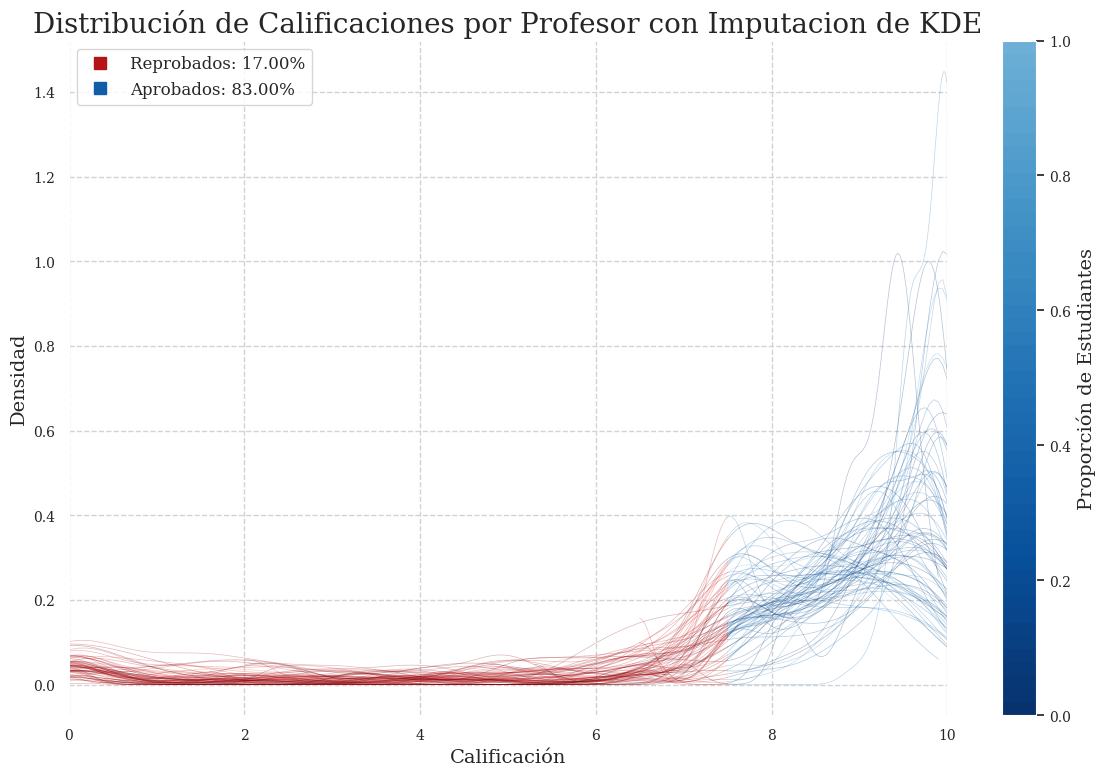

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

for num, prof_id in enumerate(profes_ids):
    profe2 = ultramerge[ultramerge['CLAVEPROFESOR'] == prof_id]
    profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]
    if profe2num.empty:
        continue

    # draw KDE invisibly to obtain its sampled x,y from seaborn
    sns.kdeplot(
        profe2num['IMPKDE'],
        cut=0, bw_adjust=0.5, clip=(0, 10),
        color='none', linewidth=0, ax=ax
    )
    x, y = ax.lines[-1].get_data()
    ax.lines[-1].remove()  # remove the invisible line

    # ensure x is strictly increasing for interpolation safety
    order = np.argsort(x)
    x, y = x[order], y[order]

    # interpolate y at the split point to avoid a visual gap
    y_thr = np.interp(threshold, x, y)

    # left segment: x <= threshold
    mask_left = x <= threshold
    x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

    # right segment: x >= threshold
    mask_right = x >= threshold
    x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

    # plot two-tone KDE
    ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=0.3)
    ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=0.3)  # put legend label on one segment only


# cosmetics
ax.set_title('Distribución de Calificaciones por Profesor con Imputacion de KDE')
ax.set_xlabel('Calificación')
ax.set_ylabel('Densidad')

# combine existing legend entries with two custom entries for the means
handles, labels = ax.get_legend_handles_labels()
stat_handles = [
    Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
    Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
]

mean_below = (ultramerge['IMPKDE'] < threshold).mean()
mean_above = (ultramerge['IMPKDE'] >= threshold).mean()
stat_labels = [
    f'Reprobados: {mean_below:.2%}',
    f'Aprobados: {mean_above:.2%}'
]
ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

ax.set_xlim(0, 10)
#  ax.set_ylim(0, 2.5)

# add a colorbar only with the range of
# use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')

plt.tight_layout()
# plt.savefig('visualizations/profes_distributions/all_professors_colors_yzoom25.png', bbox_inches='tight')
# plt.savefig('visualizations/pdfs/distribucionCalificacionesProfesorValoresTirados.pdf', bbox_inches='tight')
plt.show()

## KS clustering of professors based on IMPKDE distributions

In [ ]:
# 0) isolate valid data and enforce support
df = ultramerge[['CLAVEPROFESOR','IMPKDE']].copy()
df['IMPKDE'] = pd.to_numeric(df['IMPKDE'], errors='coerce')
df = df.dropna(subset=['IMPKDE'])
df['IMPKDE'] = df['IMPKDE'].clip(0, 10)

# 1) keep professors with enough observations
nmin = 25  # adjust
counts = df.groupby('CLAVEPROFESOR').size()
keep = counts[counts >= nmin].index
df = df[df['CLAVEPROFESOR'].isin(keep)]
prof_ids = keep.to_list()

# 2) compute pairwise KS effect sizes, group by professor and store values in a dict
groups = {k: v.values for k, v in df.groupby('CLAVEPROFESOR')['IMPKDE']}
m = len(prof_ids)
D = np.zeros((m, m), dtype=float)

for a in range(m):
    xa = groups[prof_ids[a]]
    for b in range(a+1, m):
        xb = groups[prof_ids[b]]
        ks_stat, _ = stats.ks_2samp(xa, xb, alternative='two-sided', method='auto')
        D[a, b] = D[b, a] = ks_stat  # distance in [0,1]
# diagonal already zeros



In [ ]:

# this in a dataframe for convenience
D_df = pd.DataFrame(D, index=prof_ids, columns=prof_ids)

c:\Users\herie\miniconda3\envs\CMAT\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
c:\Users\herie\miniconda3\envs\CMAT\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


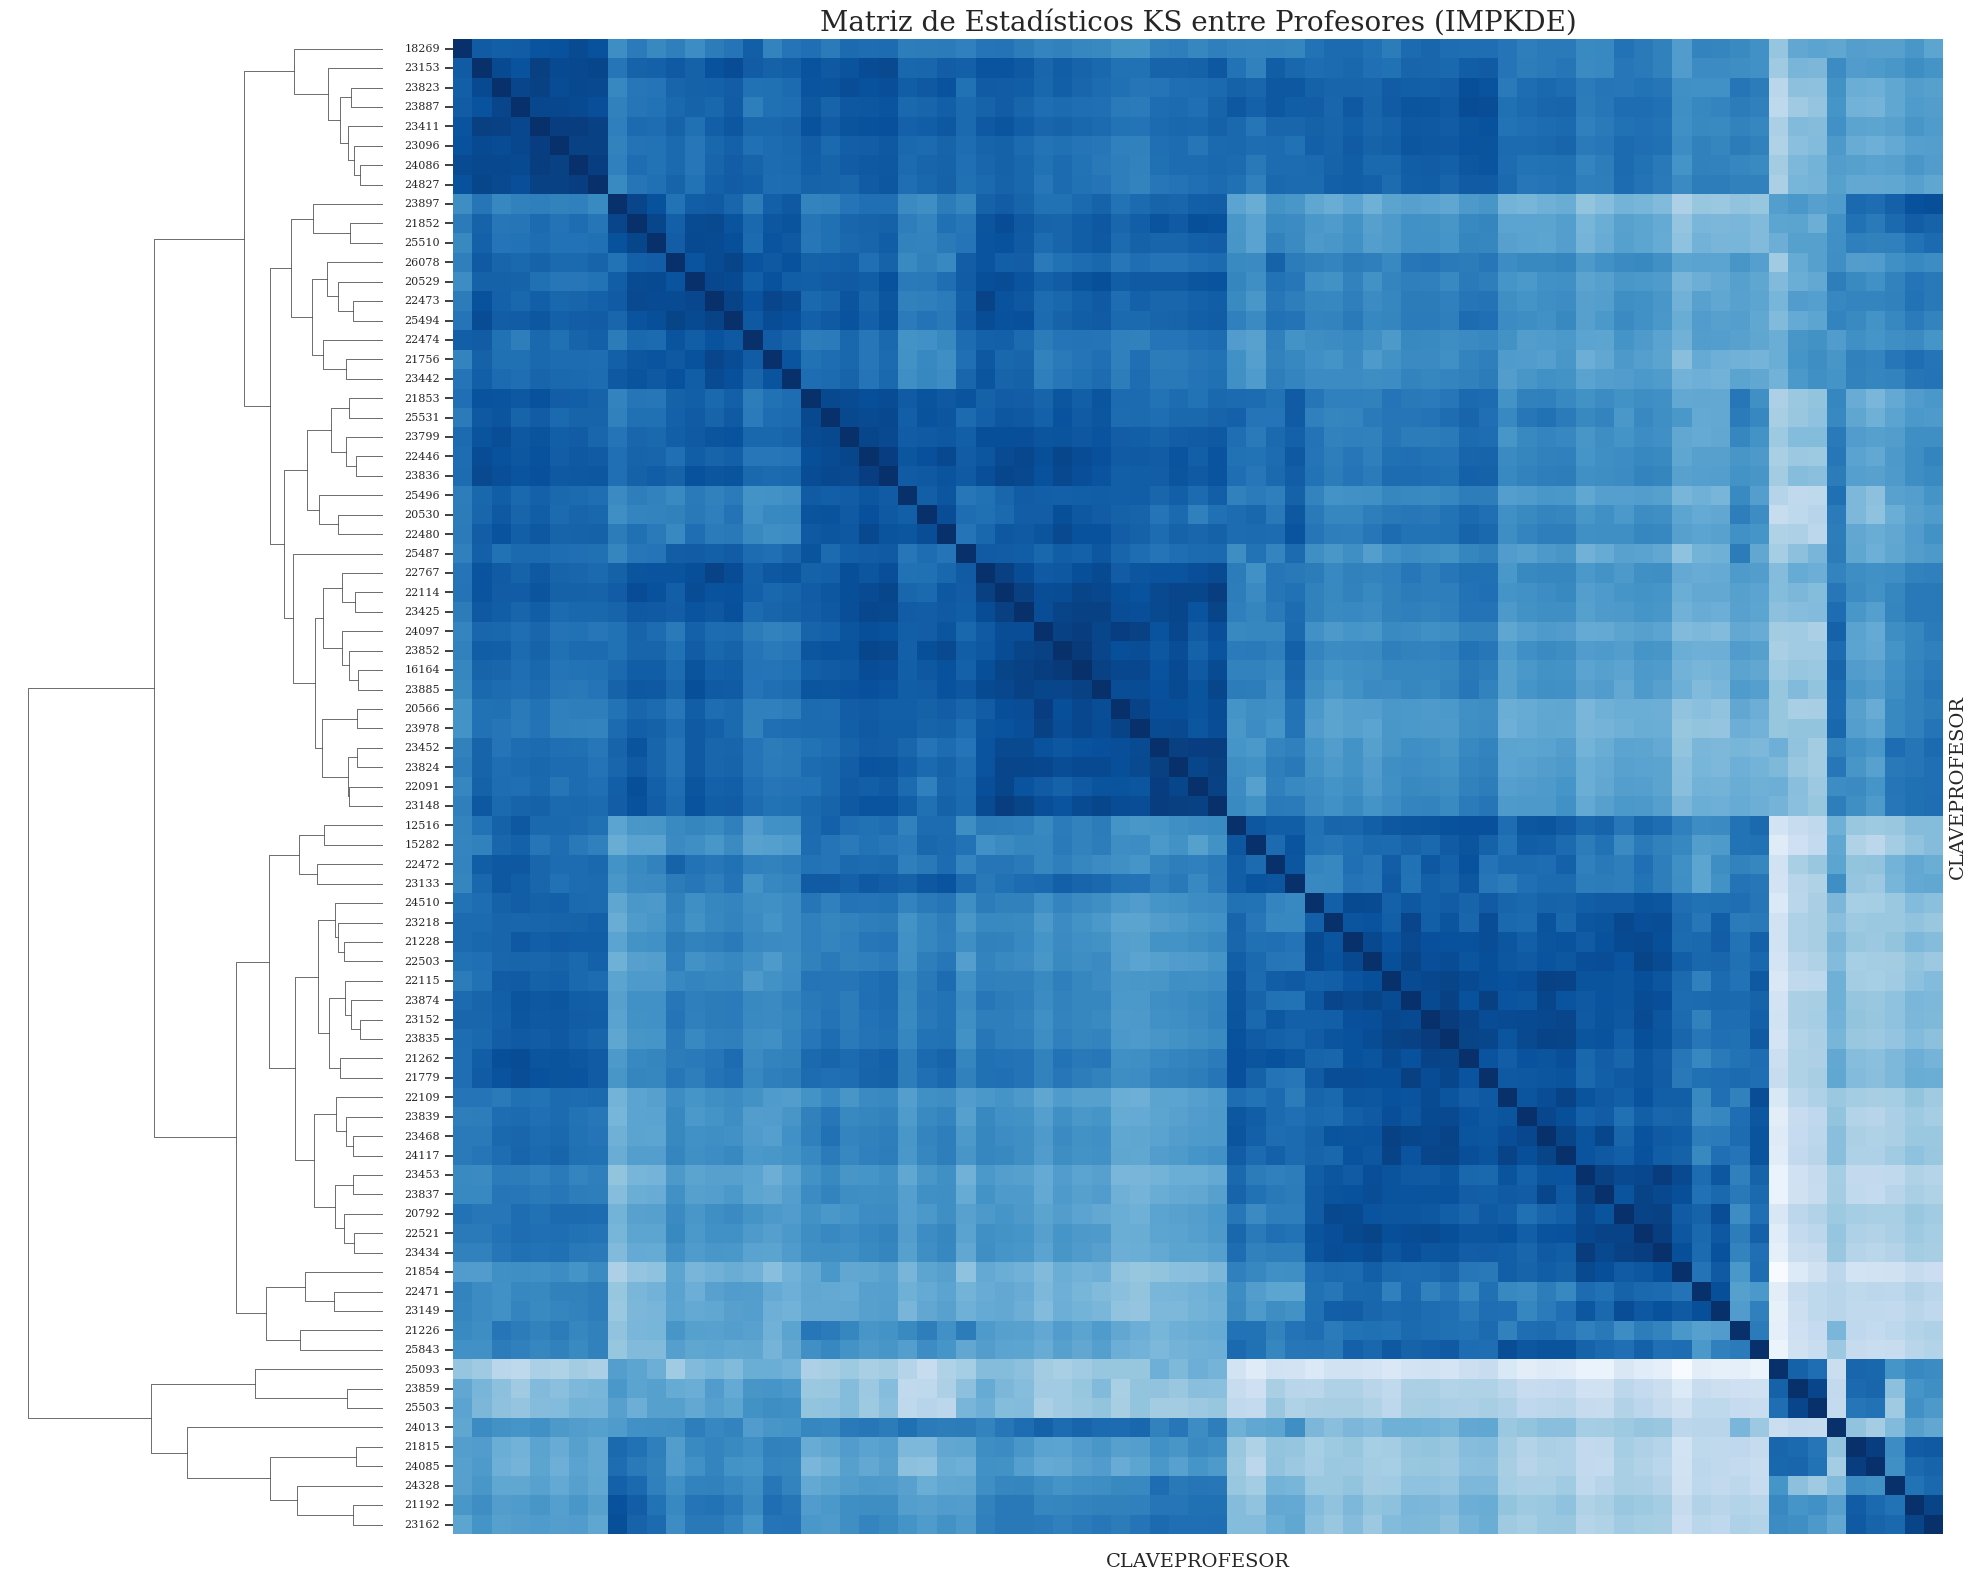

In [ ]:
# plot the ks_matrix as a clustermap heatmap
# seaborn.clustermap creates its own figure and colorbar; capture the returned ClusterGrid

g = sns.clustermap(D_df, cmap='Blues_r', annot=False, figsize=(20, 20), xticklabels=True, yticklabels=True)

# set titles/labels on the heatmap axis
g.ax_heatmap.set_title('Matriz de Estadísticos KS entre Profesores (IMPKDE)')
g.ax_heatmap.set_xlabel('CLAVEPROFESOR')
g.ax_heatmap.set_ylabel('CLAVEPROFESOR')

# rotate tick labels and set small font
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# set colorbar label using the clustergrid's cax (colorbar axis)
# if hasattr(g, 'cax') and g.cax is not None:
# hide colorbar
if hasattr(g, 'cax') and g.cax is not None:
    g.cax.set_visible(False)
	
# hide the top cluster dendrogram
g.ax_col_dendrogram.set_visible(False)

# move the labels from right side to left side
g.ax_heatmap.yaxis.set_label_position("right")
g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.yaxis.set_ticks_position("left")

# dont show x tick labels 
g.ax_heatmap.xaxis.set_ticklabels([])

plt.tight_layout()
plt.show()

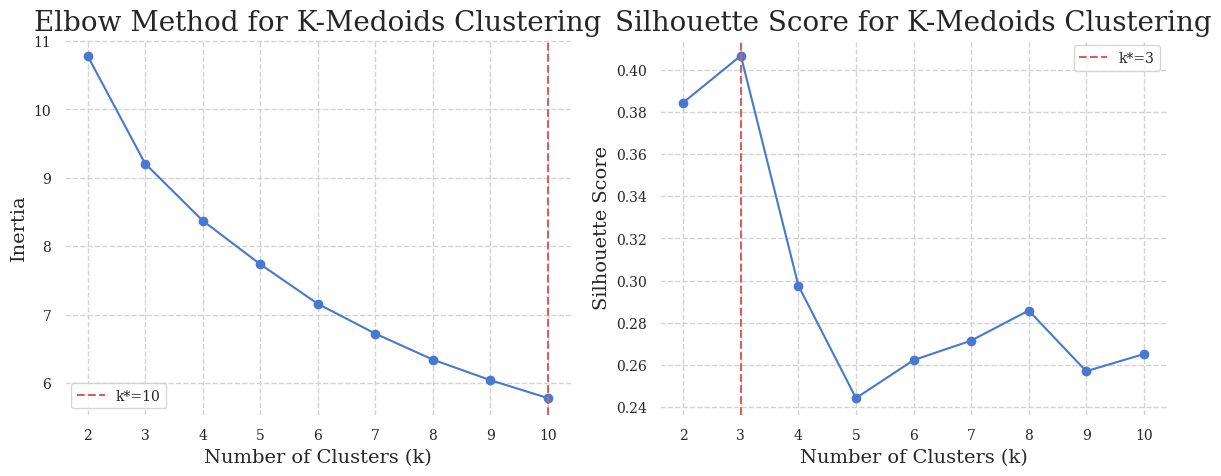

In [ ]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

ks = range(2, 11)
elbow, sils = [], []

for k in ks:
    best_inertia, best_labels = np.inf, None
    for seed in range(20):
        km = KMedoids(n_clusters=k, metric='precomputed', method='pam',
                      init='k-medoids++', random_state=seed)
        km.fit(D)
        if km.inertia_ < best_inertia:
            best_inertia = km.inertia_
            best_labels  = km.labels_
    elbow.append(best_inertia)
    sils.append(silhouette_score(D, best_labels, metric='precomputed'))

k_star_elbow = ks[int(np.argmin(np.gradient(np.gradient(elbow))))]  # knee by curvature
k_star_sil   = ks[int(np.argmax(sils))]


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)    
plt.plot(ks, elbow, marker='o')
plt.axvline(k_star_elbow, color='r', linestyle='--', label=f'k*={k_star_elbow}')
plt.title('Elbow Method for K-Medoids Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.subplot(1, 2, 2)    
plt.plot(ks, sils, marker='o')
plt.axvline(k_star_sil, color='r', linestyle='--', label=f'k*={k_star_sil}')
plt.title('Silhouette Score for K-Medoids Clustering')  
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

Silhouette measures **cluster separation vs. cohesion** on a per-point basis and averages it.

# Glossary

(d(x,y)): distance.
(C(i)): cluster containing point (i).
(a(i)): mean distance from (i) to points in (C(i)) (intra-cluster).
(b(i)): minimum, over all other clusters (C\neq C(i)), of the mean distance from (i) to (C) (nearest other cluster).
(s(i)): silhouette of (i).
(\bar s): mean silhouette over all points.

# Definition

For each point (i):
[
a(i)=\frac{1}{|C(i)|-1}\sum_{j\in C(i),,j\neq i} d(i,j),\qquad
b(i)=\min_{C\neq C(i)}\frac{1}{|C|}\sum_{j\in C} d(i,j).
]
[
\boxed{,s(i)=\frac{b(i)-a(i)}{\max{a(i),,b(i)}}\in[-1,1],}
]
Aggregate with (\bar s=\frac{1}{n}\sum_i s(i)).

# Interpretation

* (s(i)\approx 1): well inside its cluster, far from others.
* (s(i)\approx 0): on a boundary between clusters.
* (s(i)<0): closer to another cluster than to its own → likely misassigned.
* (\bar s) compares different (k): larger is better, but it typically declines as (k) increases because clusters get tighter but also closer.

# For your plot

* Distance is the **KS effect size (D)**. Using `metric='precomputed'` is valid.
* The right panel says the cleanest global separation occurs at (k=2) ((\bar s\approx0.5)).
* For (k\ge4) the silhouettes flatten at (\approx0.27!-!0.31): clusters exist but are **overlapping**.
* Combine with the elbow: choose the **smallest (k)** past the inertia knee that still keeps (\bar s) acceptable. Here that argues for (k=2) or (k=3) unless domain reasons require finer strata.

# Practical checks

* Inspect the **distribution of (s(i))** by cluster. Low-median clusters are weak or too small.
* Validate stability by bootstrapping; prefer (k) with high median (s(i)) and stable medoids.
* If distances are non-metric or noisy, also report **Wasserstein** or **energy distance** silhouettes for sensitivity.

> “What is not measured is not managed.” — often attributed to Drucker.

[
\boxed{\bar s(k)=\frac{1}{n}\sum_i\frac{b(i)-a(i)}{\max{a(i),b(i)}},\ \text{pick }k\text{ maximizing }\bar s\text{ subject to an inertia knee}}
]


In [ ]:
# cluster with k=4
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids.fit(D_df.to_numpy())
ultramerge['KS_CLUSTER'] = ultramerge['CLAVEPROFESOR'].map(
    dict(zip(D_df.index, kmedoids.labels_))
)

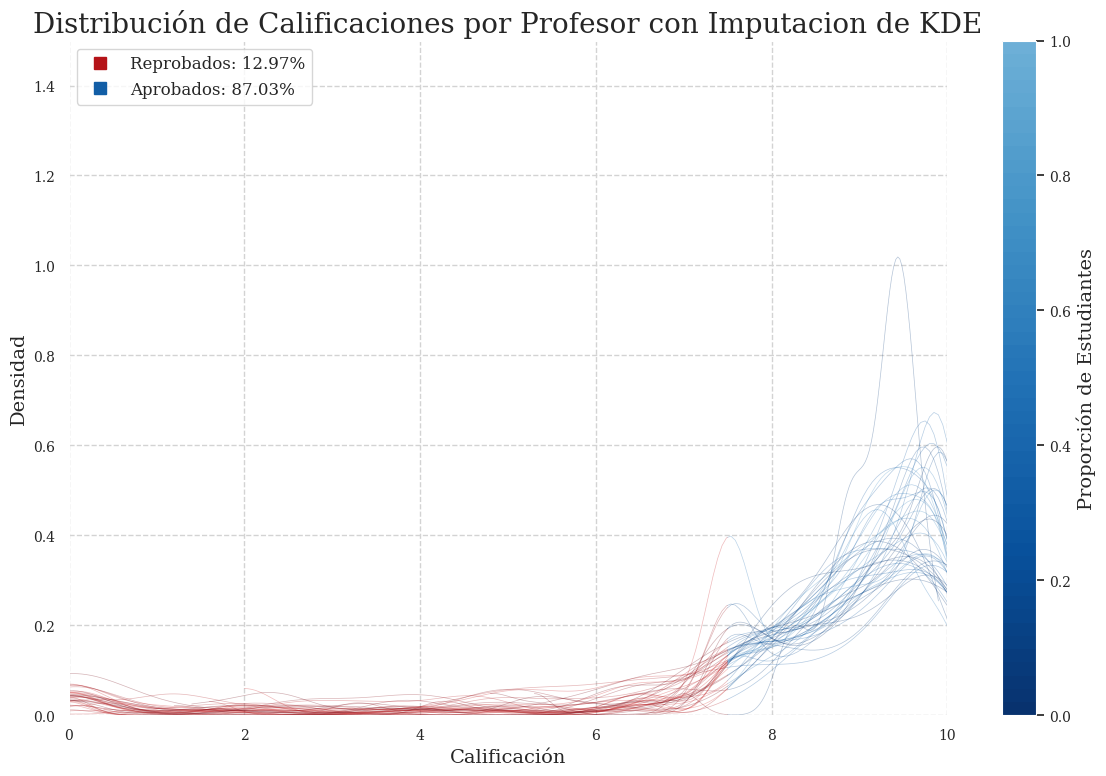

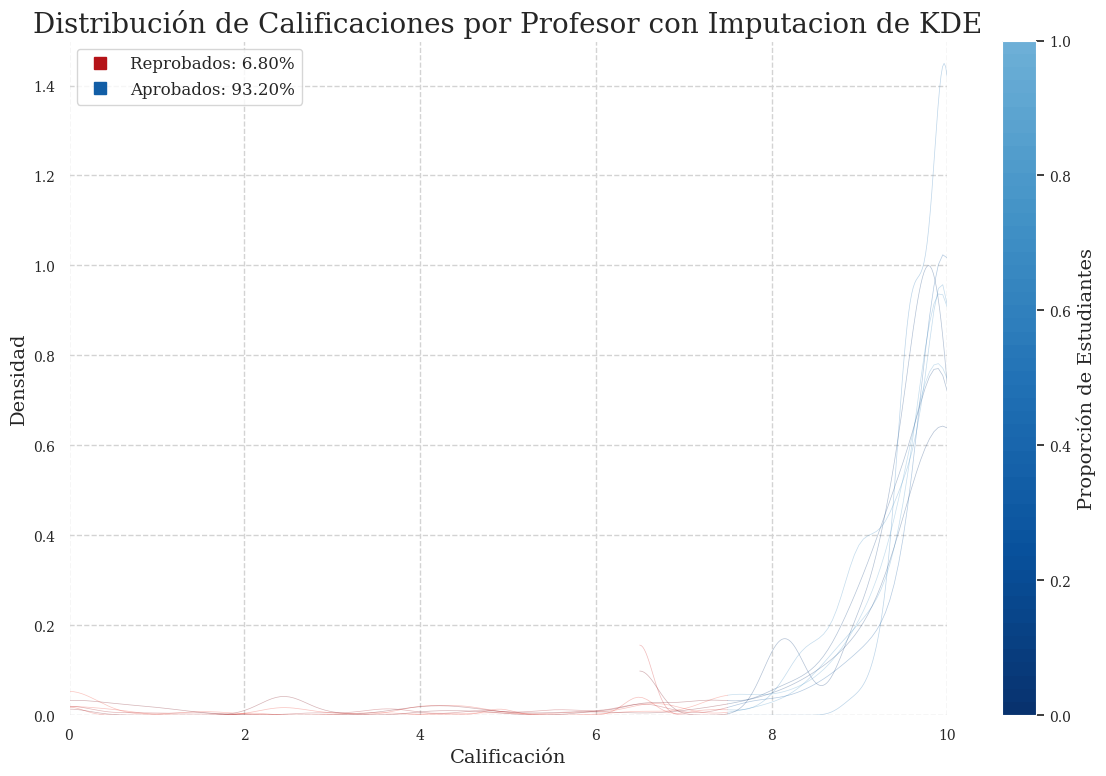

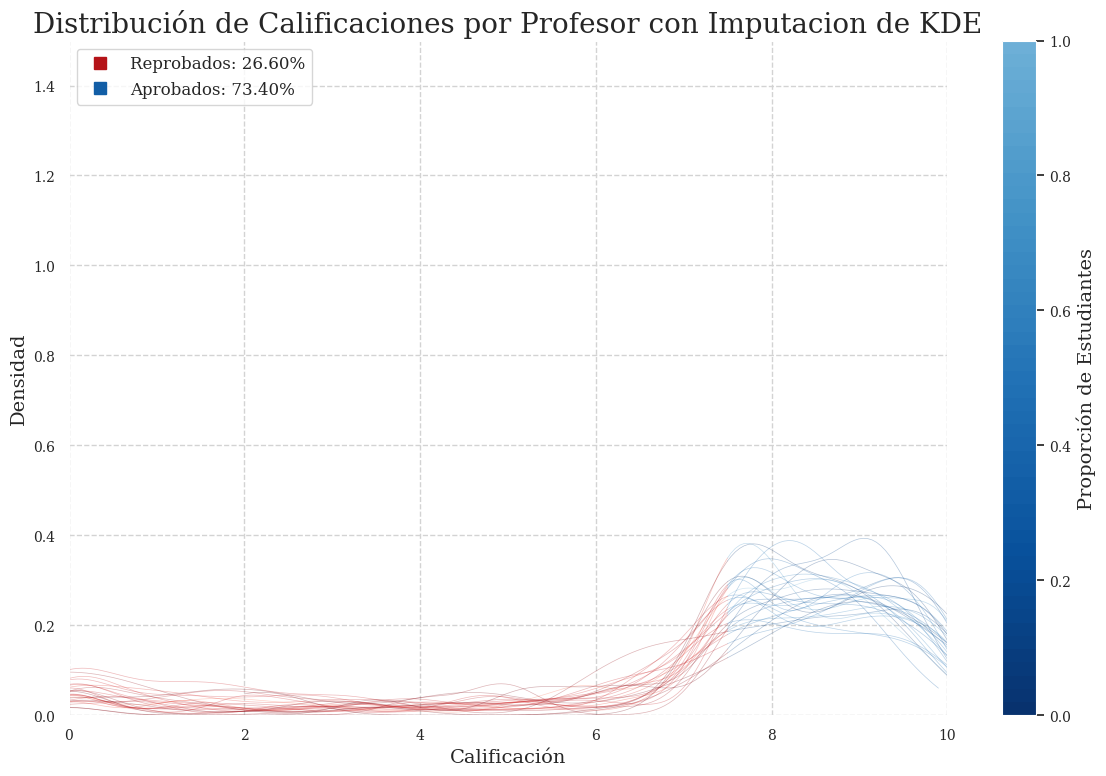

In [ ]:
for i in range(3):

    fig, ax = plt.subplots(figsize=(12, 8))

    k1 = ultramerge[ultramerge['KS_CLUSTER'] == i]

    for num, prof_id in enumerate(profes_ids):
        profe2 = k1[k1['CLAVEPROFESOR'] == prof_id]
        profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]
        if profe2num.empty:
            continue

        # draw KDE invisibly to obtain its sampled x,y from seaborn
        sns.kdeplot(
            profe2num['IMPKDE'],
            cut=0, bw_adjust=0.5, clip=(0, 10),
            color='none', linewidth=0, ax=ax
        )
        x, y = ax.lines[-1].get_data()
        ax.lines[-1].remove()  # remove the invisible line

        # ensure x is strictly increasing for interpolation safety
        order = np.argsort(x)
        x, y = x[order], y[order]

        # interpolate y at the split point to avoid a visual gap
        y_thr = np.interp(threshold, x, y)

        # left segment: x <= threshold
        mask_left = x <= threshold
        x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

        # right segment: x >= threshold
        mask_right = x >= threshold
        x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

        # plot two-tone KDE
        ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=0.3)
        ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=0.3)  # put legend label on one segment only


    # cosmetics
    ax.set_title('Distribución de Calificaciones por Profesor con Imputacion de KDE')
    ax.set_xlabel('Calificación')
    ax.set_ylabel('Densidad')

    # combine existing legend entries with two custom entries for the means
    handles, labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
        Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
    ]
    mean_below = (k1['IMPKDE'] < threshold).mean()
    mean_above = (k1['IMPKDE'] >= threshold).mean()
    stat_labels = [
        f'Reprobados: {mean_below:.2%}',
        f'Aprobados: {mean_above:.2%}'
    ]
    ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1.5)

    # add a colorbar only with the range of
    # use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)

    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)

    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')

    plt.tight_layout()
    # plt.savefig('visualizations/profes_distributions/all_professors_colors_yzoom25.png', bbox_inches='tight')
    # plt.savefig('visualizations/pdfs/distribucionCalificacionesProfesorValoresTirados.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
SQRT_2PI = np.sqrt(2*np.pi)

def silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = sd if iqr <= 0 else min(sd, iqr/1.34)
    return 0.9 * s * n**(-1/5)

def kde_gaussian_grid(x_grid, sample, h):
    # x_grid: (m,), sample: (n,), returns f_hat(x_grid): (m,)
    Z = (x_grid[:, None] - sample[None, :]) / h        # (m,n)
    return np.exp(-0.5 * Z**2).sum(axis=1) / (len(sample) * h * SQRT_2PI)

def kde_bootstrap_ci(x_grid, sample, h, B=200, q=(2.5, 97.5), rng=None):
    rng = np.random.default_rng(None if rng is None else rng)
    n = len(sample)
    m = len(x_grid)
    boot = np.empty((B, m), dtype=float)
    idx = np.arange(n)
    for b in range(B):
        resample = sample[rng.integers(0, n, n)]
        boot[b] = kde_gaussian_grid(x_grid, resample, h)
    lo, hi = np.percentile(boot, q, axis=0)
    return lo, hi


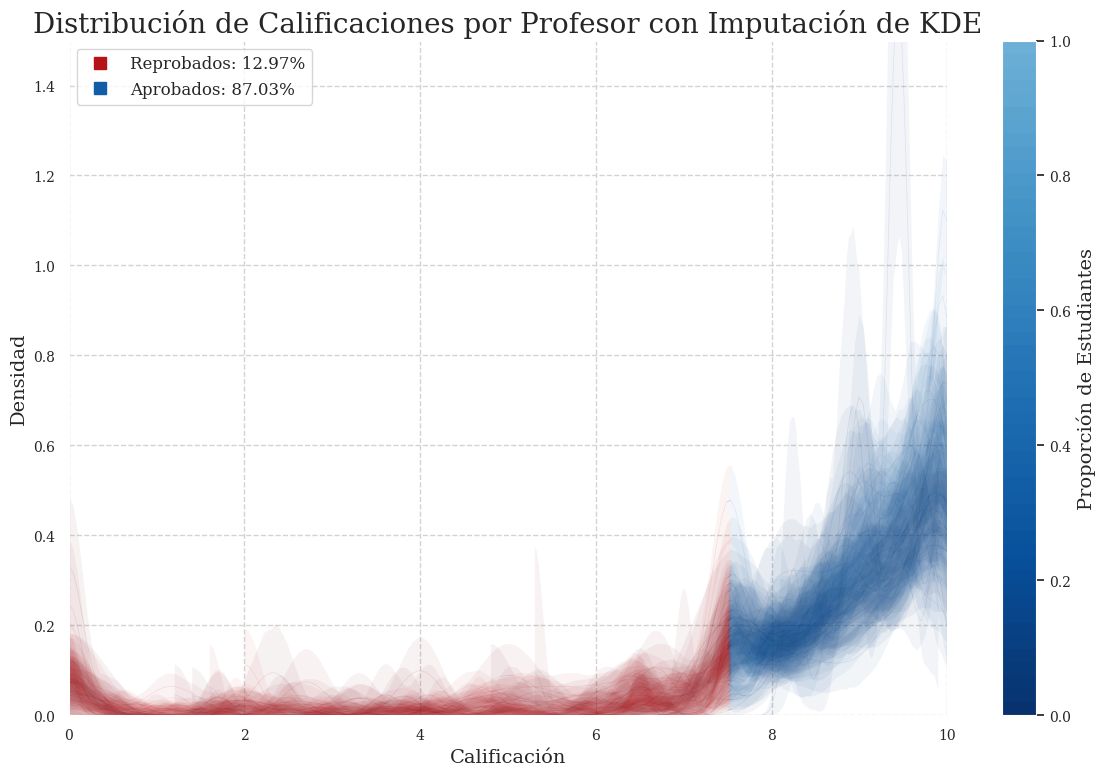

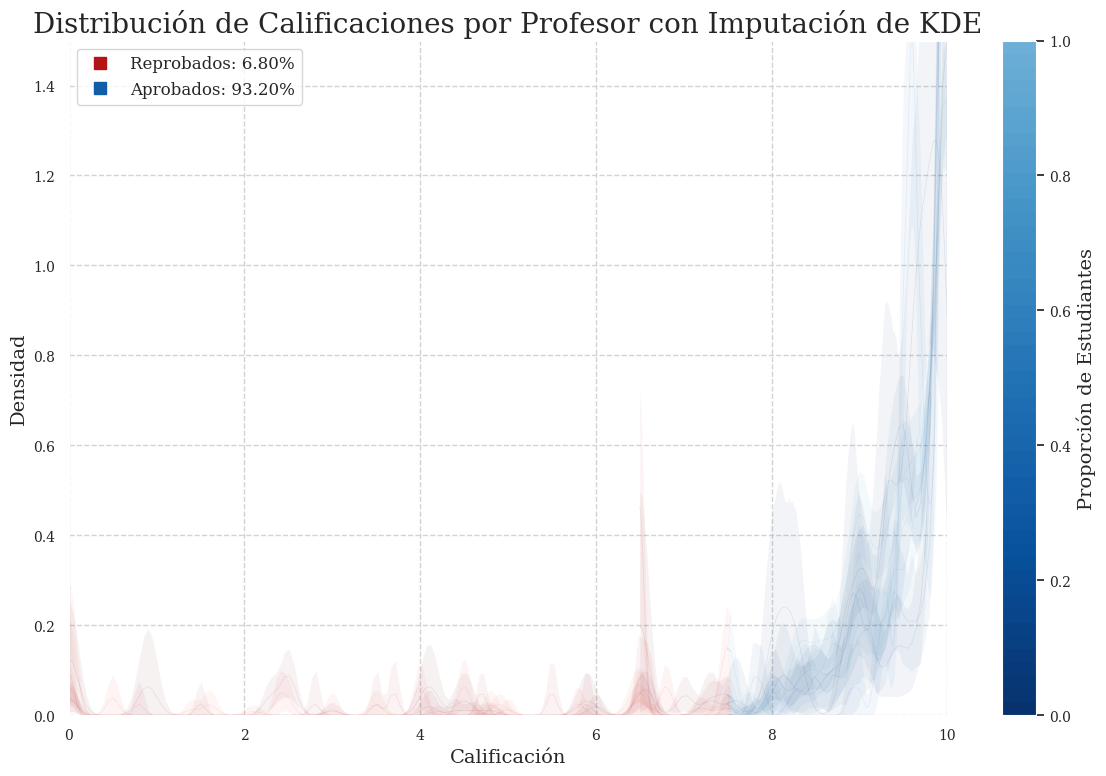

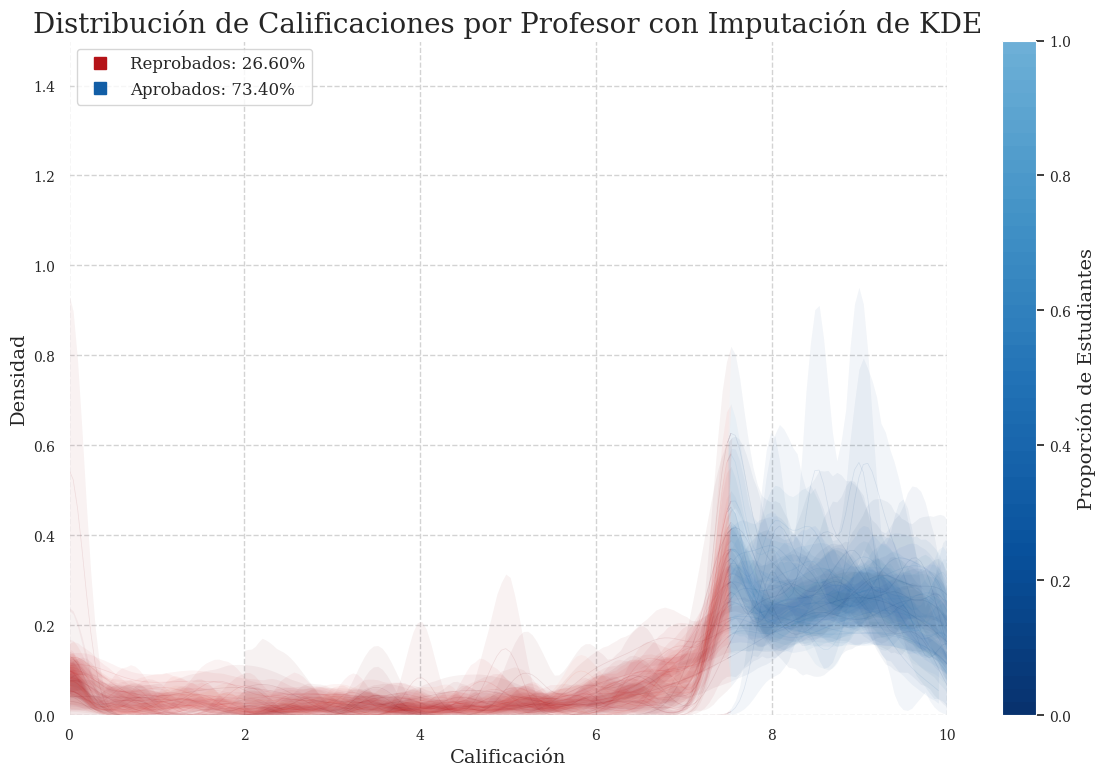

In [ ]:
for i in range(3):
    fig, ax = plt.subplots(figsize=(12, 8))
    k1 = ultramerge[ultramerge['KS_CLUSTER'] == i]

    bw_adj = 0.5
    B = 200          # bootstrap replicates
    alpha_line = 0.1
    alpha_band = 0.05

    for num, prof_id in enumerate(profes_ids):
        profe2 = k1[k1['CLAVEPROFESOR'] == prof_id]
        profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]['IMPKDE'].to_numpy(float)
        if profe2num.size == 0:
            continue

        # draw KDE invisibly to obtain seaborn's grid
        sns.kdeplot(
            profe2num, cut=0, bw_adjust=bw_adj, clip=(0, 10),
            color='none', linewidth=0, ax=ax
        )
        x, y = ax.lines[-1].get_data()
        ax.lines[-1].remove()

        # ensure sorted grid
        order = np.argsort(x)
        x, y = x[order], y[order]

        # bandwidth: Silverman * bw_adjust on this professor's data
        h = silverman_bandwidth(profe2num) * bw_adj
        # point estimate on the same grid (to match CI computation exactly)
        y_hat = kde_gaussian_grid(x, profe2num, h)

        # bootstrap CIs at each x
        lo, hi = kde_bootstrap_ci(x, profe2num, h, B=B, q=(2.5, 97.5), rng=42)

        # split at threshold
        y_thr = np.interp(threshold, x, y_hat)

        mask_left = x <= threshold + 0.06
        mask_right = x >= threshold

        # close the split so bands do not gap
        x_left  = np.append(x[mask_left],  threshold)
        yh_left = np.append(y_hat[mask_left], y_thr)
        lo_left = np.append(lo[mask_left],   y_thr)  # conservative join
        hi_left = np.append(hi[mask_left],   y_thr)

        x_right  = np.insert(x[mask_right],  0, threshold)
        yh_right = np.insert(y_hat[mask_right], 0, y_thr)
        lo_right = np.insert(lo[mask_right],   0, y_thr)
        hi_right = np.insert(hi[mask_right],   0, y_thr)

        # plot bands first, then lines
        ax.fill_between(x_left,  lo_left,  hi_left,
                        color=magma_by_prof[num], alpha=alpha_band, linewidth=0)
        ax.fill_between(x_right, lo_right, hi_right,
                        color=viridis_by_prof[num], alpha=alpha_band, linewidth=0)

        ax.plot(x_left,  yh_left,  color=magma_by_prof[num],  linewidth=0.5, alpha=alpha_line)
        ax.plot(x_right, yh_right, color=viridis_by_prof[num], linewidth=0.5, alpha=alpha_line)

    # cosmetics unchanged
    ax.set_title('Distribución de Calificaciones por Profesor con Imputación de KDE')
    ax.set_xlabel('Calificación')
    ax.set_ylabel('Densidad')

    handles, labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
        Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
    ]
    mean_below = (k1['IMPKDE'] < threshold).mean()
    mean_above = (k1['IMPKDE'] >= threshold).mean()
    stat_labels = [f'Reprobados: {mean_below:.2%}', f'Aprobados: {mean_above:.2%}']
    ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1.5)

    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)
    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')

    plt.tight_layout()
    plt.show()
